## Goal

Here, we compare chromosome 8 of the human genome from X or Y-bearing sperm.

1) Obtain eigenvector 1 (E1 track) 

NEXT NOTEBOOK

2) apply pymc model (train on data)
3) obtain confidence intervals
4) quantify differences

In [1]:
import cooler
import cooltools
import bioframe
import numpy as np
import pandas as pd

# Chosen resolution
resolution = 100_000

clrX = cooler.Cooler(f"../../data/human_sperm_haplo_seperated/sperm_X.merged.mcool::resolutions/{resolution}")
clrY = cooler.Cooler(f"../../data/human_sperm_haplo_seperated/sperm_Y.merged.mcool::resolutions/{resolution}")

# Read binned GC content
gc_cov = pd.read_csv(f"../data/bins/gc.{resolution}.tsv", sep="\t")

In [2]:
display(
    clrX.info,
    clrY.info
)
gc_cov.head(10).style.format({})

{'bin-size': 100000,
 'bin-type': 'fixed',
 'creation-date': '2025-06-20T10:33:35.958767',
 'format': 'HDF5::Cooler',
 'format-url': 'https://github.com/open2c/cooler',
 'format-version': 3,
 'generated-by': 'cooler-0.10.2',
 'genome-assembly': 'unknown',
 'metadata': {},
 'nbins': 31134,
 'nchroms': 194,
 'nnz': 47688802,
 'storage-mode': 'symmetric-upper',
 'sum': 94109833}

{'bin-size': 100000,
 'bin-type': 'fixed',
 'creation-date': '2025-06-20T10:32:40.894779',
 'format': 'HDF5::Cooler',
 'format-url': 'https://github.com/open2c/cooler',
 'format-version': 3,
 'generated-by': 'cooler-0.10.2',
 'genome-assembly': 'unknown',
 'metadata': {},
 'nbins': 31134,
 'nchroms': 194,
 'nnz': 40290758,
 'storage-mode': 'symmetric-upper',
 'sum': 77836378}

,chrom,start,end,GC
0,chr1,0,100000,0.449850
1,chr1,100000,200000,0.479110
2,chr1,200000,300000,0.440770
3,chr1,300000,400000,0.411210
4,chr1,400000,500000,0.381890
5,chr1,500000,600000,0.382540
6,chr1,600000,700000,0.408710
7,chr1,700000,800000,0.376220
8,chr1,800000,900000,0.365910
9,chr1,900000,1000000,0.366420


In [3]:
# Make viewframes
assembly = "GRCh38"
centromeres = bioframe.fetch_centromeres(assembly)
chromsizes = bioframe.fetch_chromsizes(assembly)
chromarms = bioframe.make_chromarms(chromsizes, centromeres)
view = bioframe.make_viewframe(chromarms).query('chrom == "chr8"').reset_index(drop=True)
view

,chrom,start,end,name
0,chr8,0,45200000,chr8_p
1,chr8,45200000,145138636,chr8_q


## Eigendecomposition

In [4]:
import cooler
import cooltools
import bioframe
import numpy as np
import pandas as pd

# Chosen resolution
resolutions = [100_000, 50_000, 10_000]

eig_dict = {}

for resolution in resolutions:
    eig_dict[resolution] = {}
    print(f"Processing resolution: {resolution}")
    clrX = cooler.Cooler(f"../../data/human_sperm_haplo_seperated/sperm_X.merged.mcool::resolutions/{resolution}")
    clrY = cooler.Cooler(f"../../data/human_sperm_haplo_seperated/sperm_Y.merged.mcool::resolutions/{resolution}")

    # Read binned GC content
    gc_cov = pd.read_csv(f"../data/bins/gc.{resolution}.tsv", sep="\t")
    eigval_x, df_e1_x = cooltools.eigs_cis(
        clrX, 
        gc_cov,
        view, 
        n_eigs=3,
        sort_metric='spearmanr'
    )

    eig_dict[resolution]['X'] = df_e1_x

    df_e1_x.to_csv(
        f"../data/eigs/sperm_X.chr8.eigs.{resolution}.cis.vecs.tsv",
        sep="\t",
        index=False
    )

    print("X is done, now processing Y", end="")

    eigval_y, df_e1_y = cooltools.eigs_cis(
        clrY, 
        gc_cov,
        view, 
        n_eigs=3,
        sort_metric='spearmanr'
    )

    eig_dict[resolution]['Y'] = df_e1_y

    df_e1_y.to_csv(
        f"../data/eigs/sperm_Y.chr8.eigs.{resolution}.cis.vecs.tsv",
        sep="\t",
        index=False
    )

    print("... done")

Processing resolution: 100000


X is done, now processing Y

... done
Processing resolution: 50000


X is done, now processing Y

... done
Processing resolution: 10000


X is done, now processing Y

... done


## Plot the E1's

In [5]:
# Load the files back as the same dict to be able to start from here next time

import cooler
import cooltools
import pandas as pd
import numpy as np

eig_dict = {}
resolutions = [10_000, 50_000, 100_000]

for resolution in resolutions:
    eig_dict[resolution] = {}
    eig_dict[resolution]['X'] = pd.read_csv(
        f"../data/eigs/sperm_X.chr8.eigs.{resolution}.cis.vecs.tsv",
        sep="\t"
    )
    eig_dict[resolution]['Y'] = pd.read_csv(
        f"../data/eigs/sperm_Y.chr8.eigs.{resolution}.cis.vecs.tsv",
        sep="\t"
    )



In [6]:
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('smaller.mplstyle')

import numpy as np


# Plot the E1 tracks saved in a dict

def plot_eigenvectors(eigenvectors, title=None, scatter=True, scatter_alpha=0.5):
    fig, ax = plt.subplots(figsize=(6, 1))

    x = eigenvectors['start']
    y = eigenvectors['E1']

    # Make stairs
    x_stairs = np.zeros(2* len(x))
    x_stairs[::2] = x
    x_stairs[1::2] = x + resolution
    y_stairs = np.zeros(2* len(y))
    y_stairs[::2] = y
    y_stairs[1::2] = y

    if scatter:
        ax.scatter(x, y, s=0.4, color='k', alpha=scatter_alpha, ec='None')
    ax.fill_between(x_stairs, y_stairs, where = y_stairs<0, color='tab:blue', lw=1, ec='None', step='post')
    ax.fill_between(x_stairs, y_stairs, where = y_stairs>0, color='tab:red', lw=1, ec='None', step='post') 
    ax.set_title(title)
    ax.set_ylabel('E1')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(-1,1)
    # ax.set_xlabel('Genomic Position (Mbp)')
    ticks = np.linspace(0, x.max(), num=10)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{int(t/1e6)} Mb' for t in ticks])
    ax.spines[:].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    fig.tight_layout()



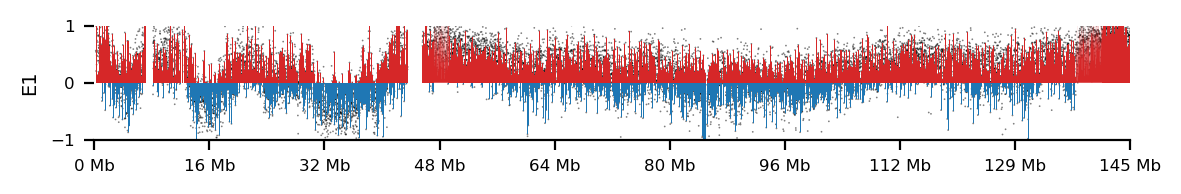

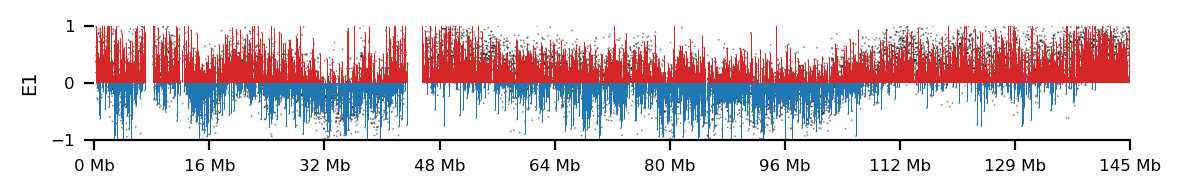

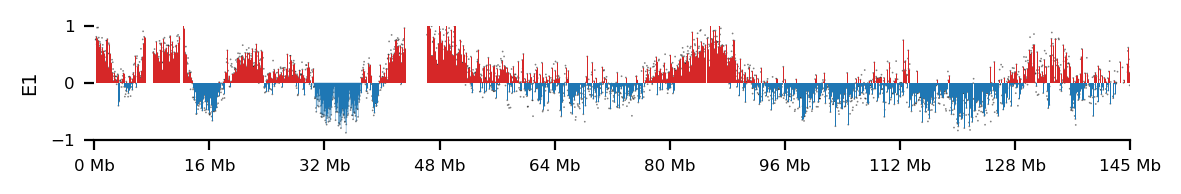

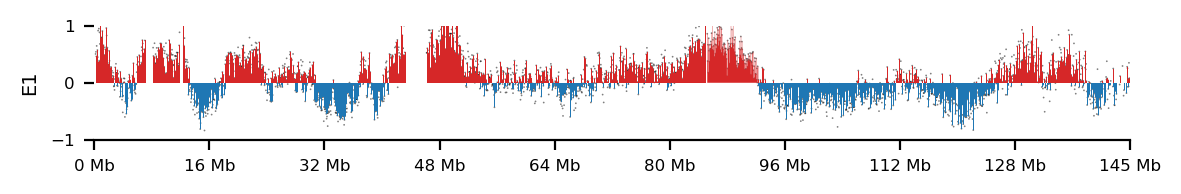

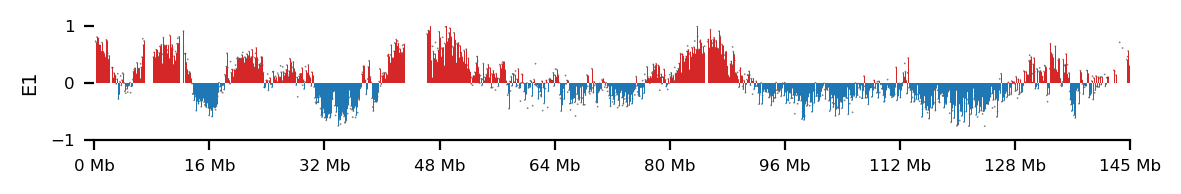

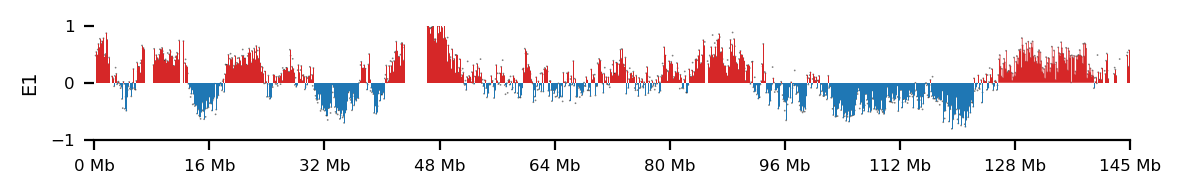

In [7]:
#| echo: false
#| label: fig-chr8-eigs
#| fig-cap: "Comparing the eigenvector E1 for chr8 in X- and Y-bearing sperm at different resolutions. Here, the eigenvectors are re-sorted by their Spearman correlation with the GC content."
#| fig-scap: "Compare chr8 E1 for X/Y-bearing sperm"
#| fig-subcap:
#|  - "E1 for X-bearing sperm (10kb)"
#|  - "E1 for Y-bearing sperm (10kb)"
#|  - "E1 for X-bearing sperm (50kb)"
#|  - "E1 for Y-bearing sperm (50kb)"
#|  - "E1 for X-bearing sperm (100kb)"
#|  - "E1 for Y-bearing sperm (100kb)"

for res, dict in eig_dict.items():
    df_e1_x = dict['X']
    df_e1_y = dict['Y']
    plot_eigenvectors(df_e1_x, 
                      title=None)
    plot_eigenvectors(df_e1_y,
                      title=None)